In [ ]:
import os

from utils import run_proteus

import torch
from botorch.models import SingleTaskGP
from botorch.models.transforms import Normalize, Standardize
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from scipy.stats.qmc import Halton

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

from botorch.acquisition import ExpectedImprovement, UpperConfidenceBound

from botorch.optim import optimize_acqf

import matplotlib.pyplot as plt

device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
dtype = torch.double



In [2]:
print(os.getcwd())
os.chdir("..")
print(os.getcwd())

/Users/benriegler/Documents/BO_Lichtenberg/PROTEUS/play_dummy
/Users/benriegler/Documents/BO_Lichtenberg/PROTEUS


In [3]:
data_path = "play_dummy/synth_data/struct.corefrac.csv"

# pick the ones that vary
output = pd.read_csv(data_path, delimiter= "\t")[["contrast_ratio",
                                               "M_planet",
                                               "R_int",
                                               "transit_depth"]]

param = pd.read_csv(data_path, delimiter= "\t")[["index"]]

out_scaler = StandardScaler()

# work with standardized observables to keep objective at reasonable size
output = out_scaler.fit_transform(torch.tensor(output.values))

# parameters will be MinMax scaled internally by BoTorch
param = torch.tensor(param.values)


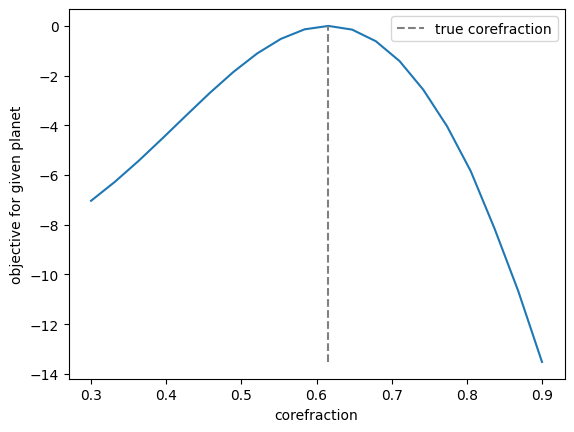

In [4]:
# choose planet from synthetic data

obs = output[10,:]; x = param[10,:]

# calculate discretized objective

f = -((output-obs)**2).sum(1)

# plot objective over normalized input

plt.plot(param, f)
plt.vlines(x,f.min(), f.max(), color = "grey", linestyles= "--", label="true corefraction")

plt.xlabel("corefraction")
plt.ylabel("objective for given planet")

plt.legend()

plt.show()

In [5]:
def J(x, obs):
    # change only the corefrac and keep rest fixed at dummy config/ at config of synthetic DGP

    # the observables of interest here
    observables = [ "contrast_ratio",
                    "M_planet",
                    "R_int",
                    "transit_depth"]

    run_name = "BO/simple_BO"

    # un-torch
    x = x.item()

    par = {"struct.corefrac": x}

    sim = run_proteus(par, run_name, observables)

    # output to torch
    sim = torch.tensor(sim.values).reshape(1, -1)
    sim = out_scaler.transform(sim) # convert to normalized scale
    J = torch.tensor(- ((obs-sim)**2).sum().reshape(1,1)) # BO Torch maximizes

    return J, sim

In [6]:
# the optimium and the optimizer
print(J(x,obs))
print(x)

(tensor([[-0.]], dtype=torch.float64), array([[0.03673628, 0.00461837, 0.07222472, 0.03939936]]))
tensor([0.6158], dtype=torch.float64)


In [7]:
bounds = torch.tensor([[0.3], [0.9]], device=device, dtype=dtype)

BATCH_SIZE = 1
NUM_RESTARTS = 10
RAW_SAMPLES = 50


def optimize_acqf_and_get_observation(acq_func, obs):
    """Optimizes the acquisition function, and returns a new candidate and observation."""
    # optimize

    candidates, _ = optimize_acqf(
        acq_function=acq_func,
        bounds=bounds,
        q=BATCH_SIZE,
        num_restarts=NUM_RESTARTS,
        raw_samples=RAW_SAMPLES,  # used for intialization heuristic
        options={"batch_limit": 5, "maxiter": 200},
    )
    # observe new values
    new_x = candidates.detach()
    new_y = J(new_x, obs)[0]

    return new_x, new_y

def init_model(train_X, train_Y):

    gp = SingleTaskGP(
    train_X=train_X,
    train_Y=train_Y,
    input_transform=Normalize(d=1),
    outcome_transform=Standardize(m=1),
    )

    mll = ExactMarginalLogLikelihood(gp.likelihood, gp)

    return mll, gp

def plot_iteration(acqf, train_X, train_Y, model):

    test_X = torch.linspace(bounds[0].item(),bounds[1].item(), 100)[:, None][:, None] # batch_shape x q=1 x d for acqf

    post = model.posterior(test_X)

    mean = post.mean.detach().numpy().flatten()
    # var = post.variance.detach().numpy().flatten()

    a = acqf(test_X).detach().numpy()

    test_X = test_X.flatten()

    plt.plot(param, f, label = "f", linewidth = 0.5, color = "grey")

    plt.plot(test_X, a, label = "acqf")

    plt.scatter(train_X, train_Y)

    plt.plot(test_X, mean, label = "post_mean")

    plt.legend()

    plt.show()

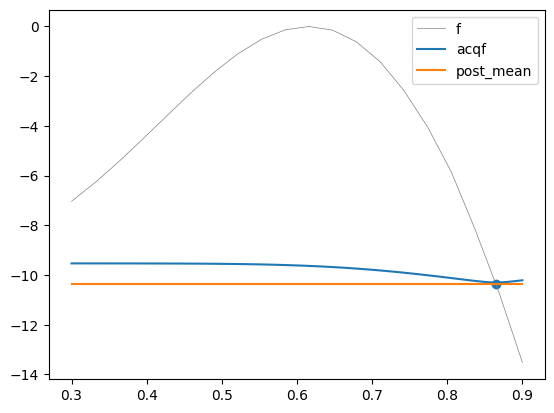

starting iteration 1


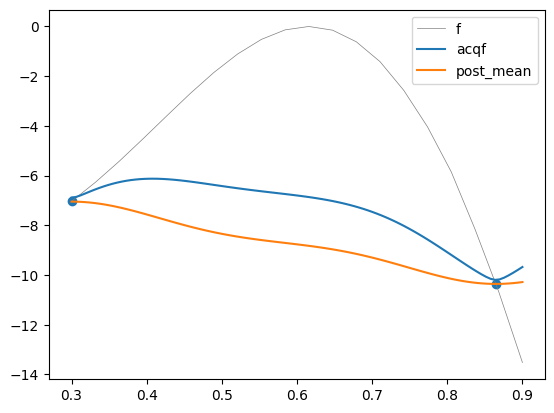

starting iteration 2


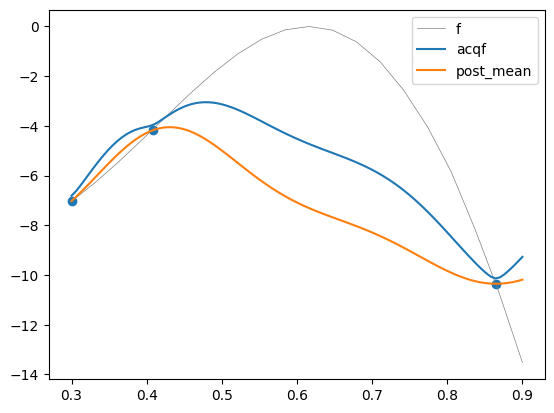

starting iteration 3


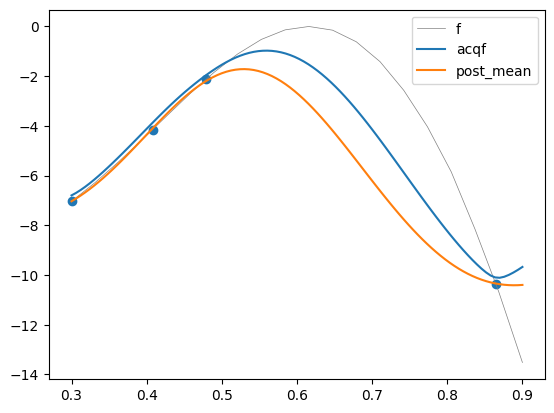

starting iteration 4


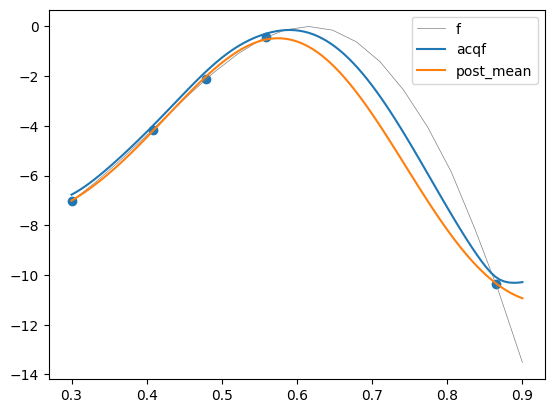

starting iteration 5


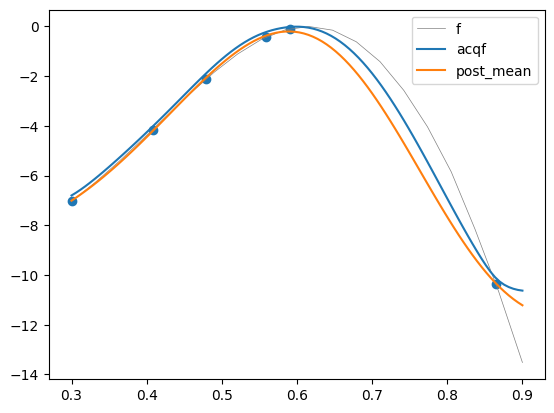

best obj: -0.09146438743478905
est: tensor([[0.5901]], dtype=torch.float64)
true: tensor([0.6158], dtype=torch.float64)


In [8]:
NUM_ITER = 5

# init data
n_init = 1

halton_sampler = Halton(d=1, scramble=True)
train_X = halton_sampler.random(n=n_init)
train_X = torch.tensor(train_X, dtype= torch.double) * (bounds[1].item() - bounds[0].item()) + bounds[0].item()

# train_X = (torch.rand(n_init, dtype=dtype) * (bounds[1].item() - bounds[0].item()) + bounds[0].item())[:, None]


train_Y = J(train_X, obs)[0]
best_y = train_Y.max()
best_x = train_X.item()

mll, gp = init_model(train_X, train_Y)
fit_gpytorch_mll(mll)

acqf = UpperConfidenceBound(model=gp, beta=0.7)
# acqf = ExpectedImprovement(gp, best_y)

plot_iteration(acqf, train_X, train_Y, gp)

for i in range(NUM_ITER):
    print(f"starting iteration {i+1}")

    new_x, new_y = optimize_acqf_and_get_observation(acqf, obs)

    if new_y > best_y:
        best_y = new_y[0][0] # change dim for EI to be happy
        best_x = new_x

    train_X = torch.cat([train_X, new_x])
    train_Y = torch.cat([train_Y, new_y])

    mll, gp = init_model(train_X, train_Y)

    fit_gpytorch_mll(mll)

    acqf = UpperConfidenceBound(model=gp, beta=0.7)
    # acqf = ExpectedImprovement(gp, best_y)

    plot_iteration(acqf, train_X, train_Y, gp)


print(f"best obj: {best_y}")
print(f"est: {best_x}")
print(f"true: {x}")
